# Credit Card Balance — Linear Regression Models

Can we predict how much credit card balance a customer carries based on their financial profile?

This notebook builds a series of OLS regression models of increasing complexity and introduces an important real-world problem: **multicollinearity** — what happens when two predictors are so closely related that the model can't tell them apart.

**Key concepts covered:**
- Simple and multiple OLS regression
- Dummy variables for categorical predictors (Yes/No, regions)
- Variance Inflation Factor (VIF) to detect multicollinearity
- Model comparison and selection


## 1. Import Libraries

In [1]:
import pandas as pd                          # data manipulation -- the core data science library
import numpy as np                             # numerical operations (sqrt, arrays)
import seaborn as sns                          # statistical visualisations
import matplotlib.pyplot as plt               # base plotting canvas
from scipy import stats                        # statistical functions: t-tests, probplot
import statsmodels.formula.api as smf          # R-style formula API for regression
import statsmodels.api as sm                   # lower-level statsmodels (used for qqplot)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF calculation
from patsy import dmatrix                      # builds design matrices (handles dummy variables)
import warnings
warnings.filterwarnings('ignore')              # suppress noisy deprecation warnings

# --- Global display settings ---
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places in all tables
sns.set_theme(style='whitegrid')               # clean white background with grid lines
plt.rcParams['figure.figsize'] = (10, 6)       # default figure size

## 2. Helper Functions

### `fit_and_plot`
Fits an OLS regression and produces a **3-panel diagnostic plot**:
- **Top**: actual vs predicted values — shows how well the model tracks the data
- **Bottom-left**: residuals vs fitted — ideally residuals scatter randomly around zero with no pattern
- **Bottom-right**: Q-Q plot — checks whether residuals follow a normal distribution (points should hug the diagonal line)

### `compute_vif`
Calculates **Variance Inflation Factors** for each predictor. VIF measures how much a predictor's coefficient is inflated due to correlation with other predictors:
- VIF = 1: no correlation with other predictors (ideal)
- VIF 1–5: moderate, usually acceptable
- VIF > 5–10: high multicollinearity — coefficients become unreliable

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    """
    Fit an OLS model and produce a 3-panel diagnostic plot.
    Returns the fitted model so it can be stored and compared later.
    """
    # smf.ols defines the model using an R-style formula like 'balance ~ rating'
    # .fit() runs the OLS calculation to find the best-fit coefficients
    model = smf.ols(formula=formula, data=data).fit()
    print(model.summary())  # print the full regression output table

    # Infer the primary x variable from the formula if the user didn't specify one
    # e.g. 'balance ~ rating + income' -> x_var = 'rating'
    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()   # outcome variable (left side of ~)
    residuals = model.resid                      # residuals = actual minus predicted

    # CRITICAL: statsmodels silently drops rows with missing (NaN) values before fitting.
    # We filter data to only the rows the model used, so our plot arrays match in length.
    model_data = data.loc[model.fittedvalues.index]

    # Check if the x variable is categorical (text) or numeric
    is_cat = model_data[x_var].dtype == object or str(model_data[x_var].dtype) == 'category'

    # Create a 2x2 grid where the top row spans the full width
    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])   # top panel spans full width
    ax_res  = fig.add_subplot(gs[1, 0])   # bottom-left
    ax_qq   = fig.add_subplot(gs[1, 1])   # bottom-right

    # --- Panel 1: Actual vs Predicted ---
    if is_cat:
        # For categorical x: jittered raw data + horizontal line at each group's predicted mean
        sns.stripplot(x=model_data[x_var], y=model_data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = model_data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        # For continuous x: black = actual, red = predicted
        # .values strips the pandas index to prevent matplotlib size-mismatch errors
        ax_main.scatter(model_data[x_var].values, model_data[y_var].values,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(model_data[x_var].values, model.fittedvalues.values,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted -- x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # --- Panel 2: Residuals vs Fitted ---
    # A well-specified model has residuals scattered randomly around the zero line.
    # A fan shape (wider spread at higher fitted values) indicates heteroscedasticity.
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')  # zero reference line
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # --- Panel 3: Q-Q Plot ---
    # Points should hug the diagonal red line if residuals are normally distributed.
    # Deviations at the tails indicate heavy tails or skewness.
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    plt.suptitle(f'{model_name}  |  R2 = {model.rsquared:.3f}  |  Adj R2 = {model.rsquared_adj:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model  # return the fitted model so we can store and compare it later


def compute_vif(df, formula_rhs):
    """
    Compute Variance Inflation Factors for all predictors in a formula.

    VIF measures how much a predictor's variance is inflated by correlation
    with other predictors. Rule of thumb: VIF > 5-10 is problematic.

    Parameters
    ----------
    df          : the DataFrame containing the data
    formula_rhs : the right-hand side of the formula (everything after ~)
                  e.g. 'income + rating + C(student)'
    """
    # dmatrix builds the design matrix -- it handles dummy variable creation
    # for categorical columns wrapped in C() automatically
    X = dmatrix(formula_rhs, data=df, return_type='dataframe')
    X = X.drop(columns='Intercept', errors='ignore')  # VIF is computed without the intercept

    # variance_inflation_factor takes the full matrix and computes VIF for each column in turn
    vif_data = pd.DataFrame({
        'feature': X.columns,
        'VIF':     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)  # sort so highest VIF shows first

    return vif_data.round(2)

print("Helper functions defined.")

Helper functions defined.


## 3. Load & Inspect Data

The credit dataset contains financial information for 400 customers: their income, credit limit, credit rating, demographics, and current credit card balance. Our goal is to predict `balance`.

In [3]:
# Read the CSV file into a pandas DataFrame
credit = pd.read_csv('../data/credit.csv')

# .shape returns (rows, columns) -- quick sanity check
print('Shape:', credit.shape)

# .dtypes shows what type each column is: int64 (integer), float64 (decimal), str (text)
print('\nColumn types:')
print(credit.dtypes)

print('\nFirst few rows:')
credit.head()

Shape: (400, 11)

Column types:
income       float64
limit          int64
rating         int64
cards          int64
age            int64
education      int64
own              str
student          str
married          str
region           str
balance        int64
dtype: object

First few rows:


,income,limit,rating,cards,age,education,own,student,married,region,balance
0,14.8910,3606,283,2,34,11,No,No,Yes,South,333
1,106.0250,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.5930,7075,514,4,71,11,No,No,No,West,580
3,148.9240,9504,681,3,36,11,Yes,No,No,West,964
4,55.8820,4897,357,2,68,16,No,No,Yes,South,331


## 4. Summary Statistics

Before building any model, we inspect the distribution of `balance` -- our outcome variable. Notice the wide range (0 to 1999) and that the mean (520) is higher than the median (459), suggesting a right-skewed distribution.

In [ ]:
# Five-number summary + mean and standard deviation for balance
print('Balance summary statistics:')
credit['balance'].describe()

## 5. Correlation Heatmap

This heatmap shows the pairwise correlations between all numeric variables. Values range from -1 (perfect negative correlation) to +1 (perfect positive correlation).

**What to look for:** `limit` and `rating` are very highly correlated with each other (r close to 1). This is a warning sign -- including both in the same model causes **multicollinearity**, which we will investigate later with VIF scores.

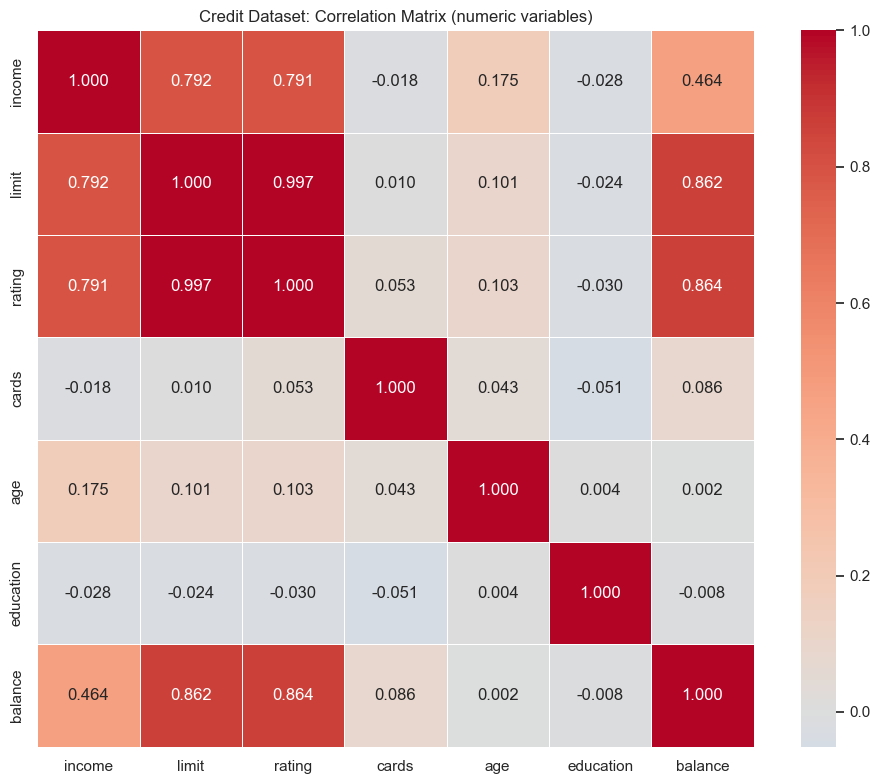

In [ ]:
# Select only the numeric columns for the correlation matrix
# Categorical columns like 'own', 'student', 'married', 'region' are excluded
vars_to_plot = ['income', 'limit', 'rating', 'cards', 'age', 'education', 'balance']
corr_matrix  = credit[vars_to_plot].corr()  # .corr() computes pairwise Pearson correlations

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,         # show the numeric correlation value in each cell
    cmap='coolwarm',    # red = positive, blue = negative, white = zero
    center=0,           # ensure white is at zero, not the midpoint of the data range
    square=True,        # make each cell a square
    fmt='.3f',          # format numbers to 3 decimal places
    linewidths=0.5      # thin grid lines between cells
)
plt.title('Credit Dataset: Correlation Matrix (numeric variables)')
plt.tight_layout()
plt.show()

## 6. Model Building

We build seven models of increasing complexity. The table below summarises what each model tests:

| Model | Formula | Key question |
|---|---|---|
| M0 | `balance ~ 1` | Baseline: just predict the mean |
| M1 | `balance ~ rating` | Does credit rating predict balance? |
| M2 | `balance ~ income` | Does income predict balance? |
| M3 | `balance ~ income + rating` | Do both together explain more? |
| M4 | `balance ~ income + rating + limit` | What happens when we add a correlated predictor? |
| M5 | `balance ~ . - limit` | All variables minus the collinear one |
| M6 | `balance ~ income + rating + age + married` | Parsimonious model with only significant predictors |

### Model 0 — Intercept Only (Baseline)

This model has no predictors. It predicts the same value (the overall mean balance of \$520) for every customer. R-squared = 0 by definition — any useful predictor should beat this.

In [6]:
# Intercept-only model: 'balance ~ 1' means 'predict a constant for everyone'
# The constant it predicts is simply the sample mean of balance
# This gives us a performance floor to compare all other models against
model0 = smf.ols('balance ~ 1', data=credit).fit()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        21:23:18   Log-Likelihood:                -3019.4
No. Observations:                 400   AIC:                             6041.
Df Residuals:                     399   BIC:                             6045.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    520.0150     22.988     22.621      0.0

### Model 1 — Credit Rating Only

Credit rating measures creditworthiness. We expect higher-rated customers to have higher balances (they qualify for more credit).

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     1168.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          1.90e-120
Time:                        21:23:21   Log-Likelihood:                -2745.4
No. Observations:                 400   AIC:                             5495.
Df Residuals:                     398   BIC:                             5503.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -390.8463     29.069    -13.446      0.0

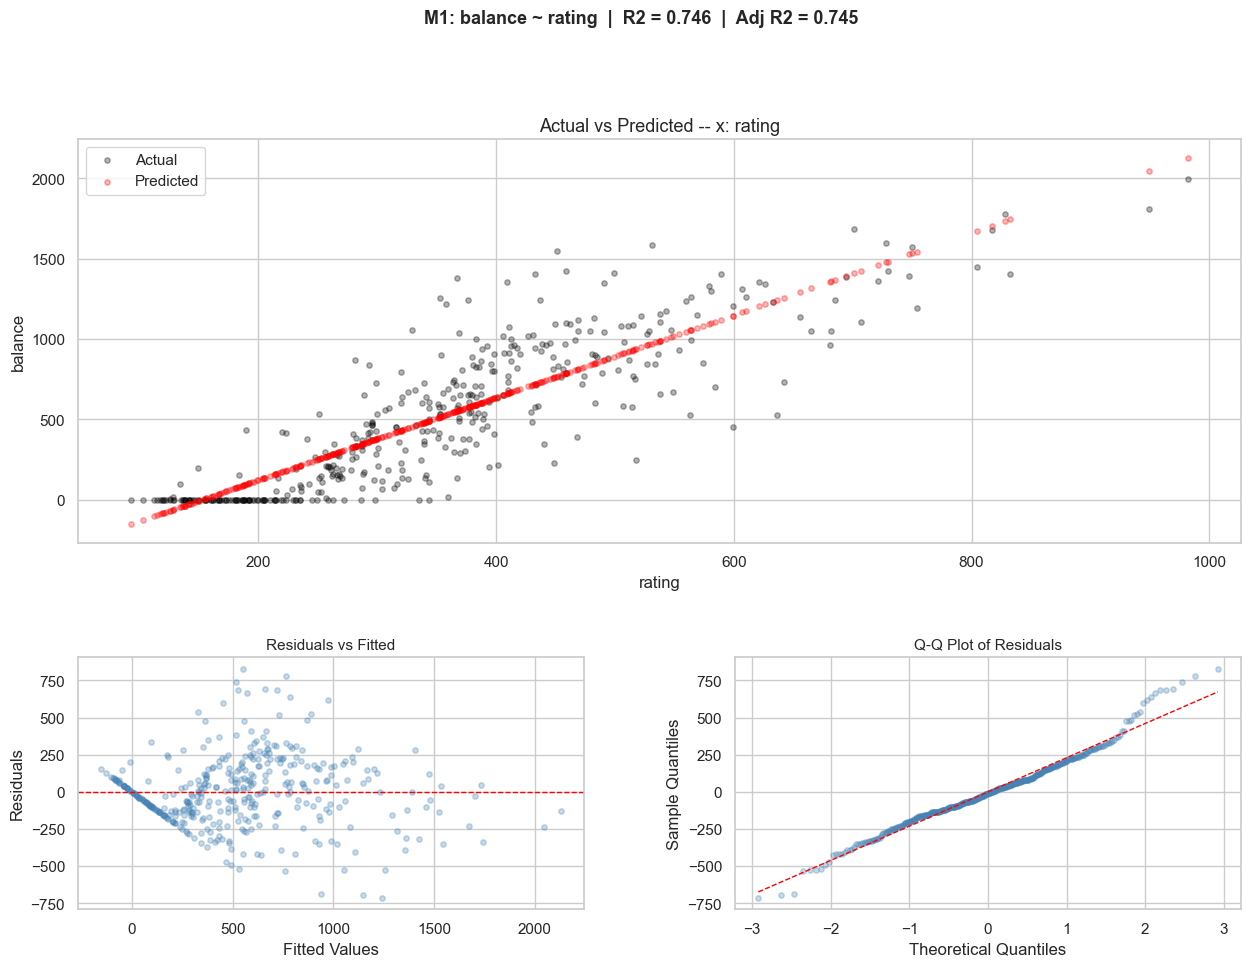

In [7]:
# rating as the single predictor
# The coefficient tells us: for each 1-point increase in credit rating,
# how many extra dollars does the model predict in balance?
model1 = fit_and_plot(
    formula='balance ~ rating',
    data=credit,
    model_name='M1: balance ~ rating',
    x_var='rating'
)

### Model 2 — Income Only

Income is another natural predictor. Interestingly, higher income might mean either higher balance (more spending) or lower balance (can pay off more each month).

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     109.0
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.03e-22
Time:                        21:23:29   Log-Likelihood:                -2970.9
No. Observations:                 400   AIC:                             5946.
Df Residuals:                     398   BIC:                             5954.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    246.5148     33.199      7.425      0.0

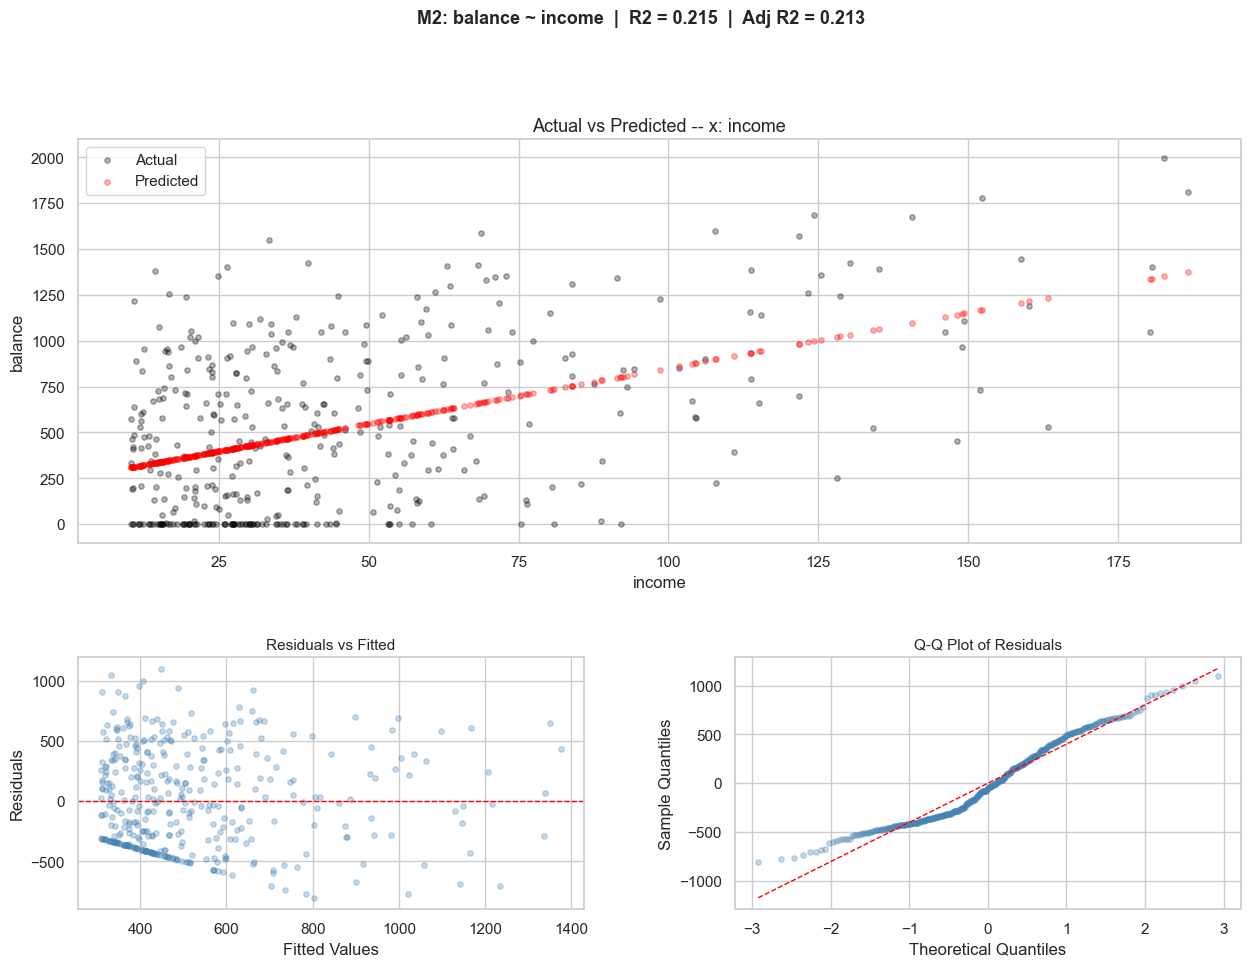

In [8]:
# income as the single predictor
# Compare the R-squared with Model 1 -- which variable explains more of balance?
model2 = fit_and_plot(
    formula='balance ~ income',
    data=credit,
    model_name='M2: balance ~ income',
    x_var='income'
)

### Model 3 — Income + Rating

Adding a second predictor: do income and rating together explain more variance than either alone?

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1391.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          4.52e-180
Time:                        21:23:34   Log-Likelihood:                -2603.3
No. Observations:                 400   AIC:                             5213.
Df Residuals:                     397   BIC:                             5225.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -534.8122     21.603    -24.757      0.0

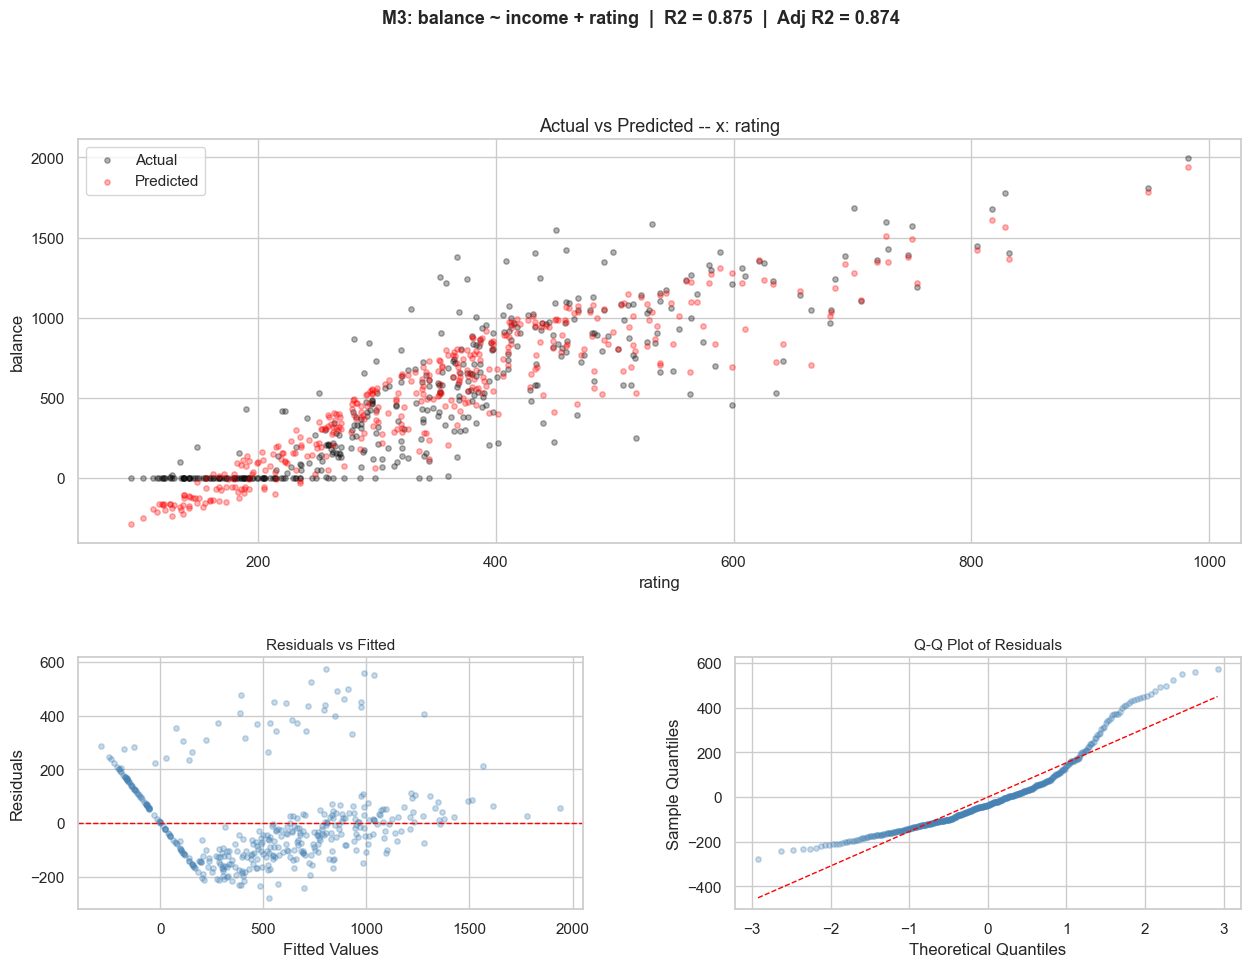

In [9]:
# Both income and rating as predictors
# Each coefficient now represents the effect of that variable *holding the other constant*
# This is called a 'partial effect' or 'ceteris paribus' interpretation
model3 = fit_and_plot(
    formula='balance ~ income + rating',
    data=credit,
    model_name='M3: balance ~ income + rating',
    x_var='rating'
)

### Model 4 — Income + Rating + Limit

We add `limit` (credit limit). From the heatmap we saw that `rating` and `limit` are very highly correlated. Watch what happens to the coefficients and standard errors when we add a collinear predictor — they become unstable.

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     934.6
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          3.20e-179
Time:                        21:23:43   Log-Likelihood:                -2601.5
No. Observations:                 400   AIC:                             5211.
Df Residuals:                     396   BIC:                             5227.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -489.7275     32.099    -15.257      0.0

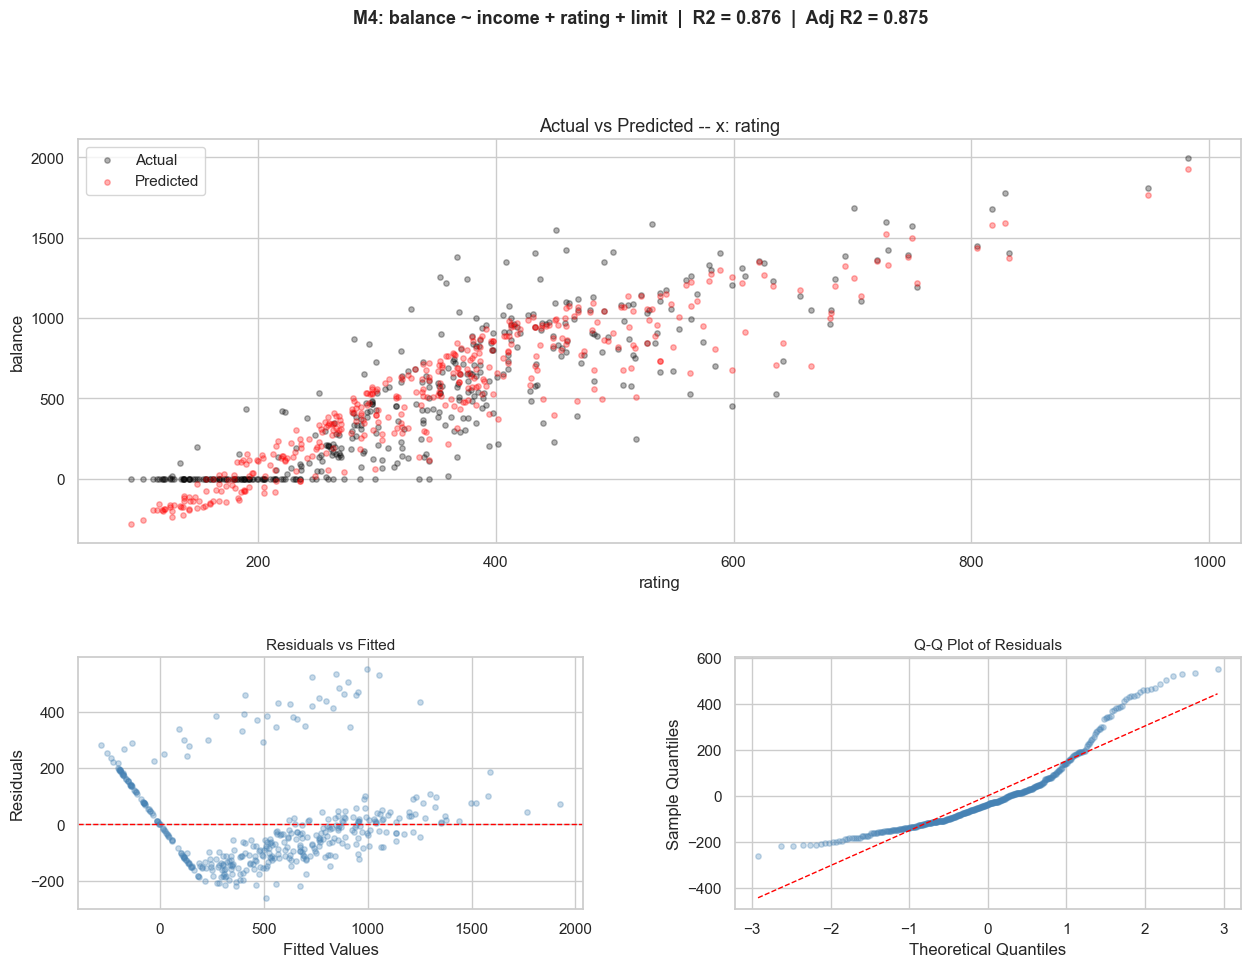

In [10]:
# Adding limit alongside rating -- these two are highly correlated
# When two predictors are correlated, the model struggles to separate their individual effects
# This shows up as large standard errors and sometimes unexpected coefficient signs
model4 = fit_and_plot(
    formula='balance ~ income + rating + limit',
    data=credit,
    model_name='M4: balance ~ income + rating + limit',
    x_var='rating'
)

### Full Model + VIF Check

We build a kitchen-sink model with all variables, then use **VIF scores** to formally diagnose multicollinearity. We build the formula dynamically so categorical columns get wrapped in `C()` for dummy variable creation.

Full formula: balance ~ income + limit + rating + cards + age + education + own + student + married + region
                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          1.11e-253
Time:                        21:26:10   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------

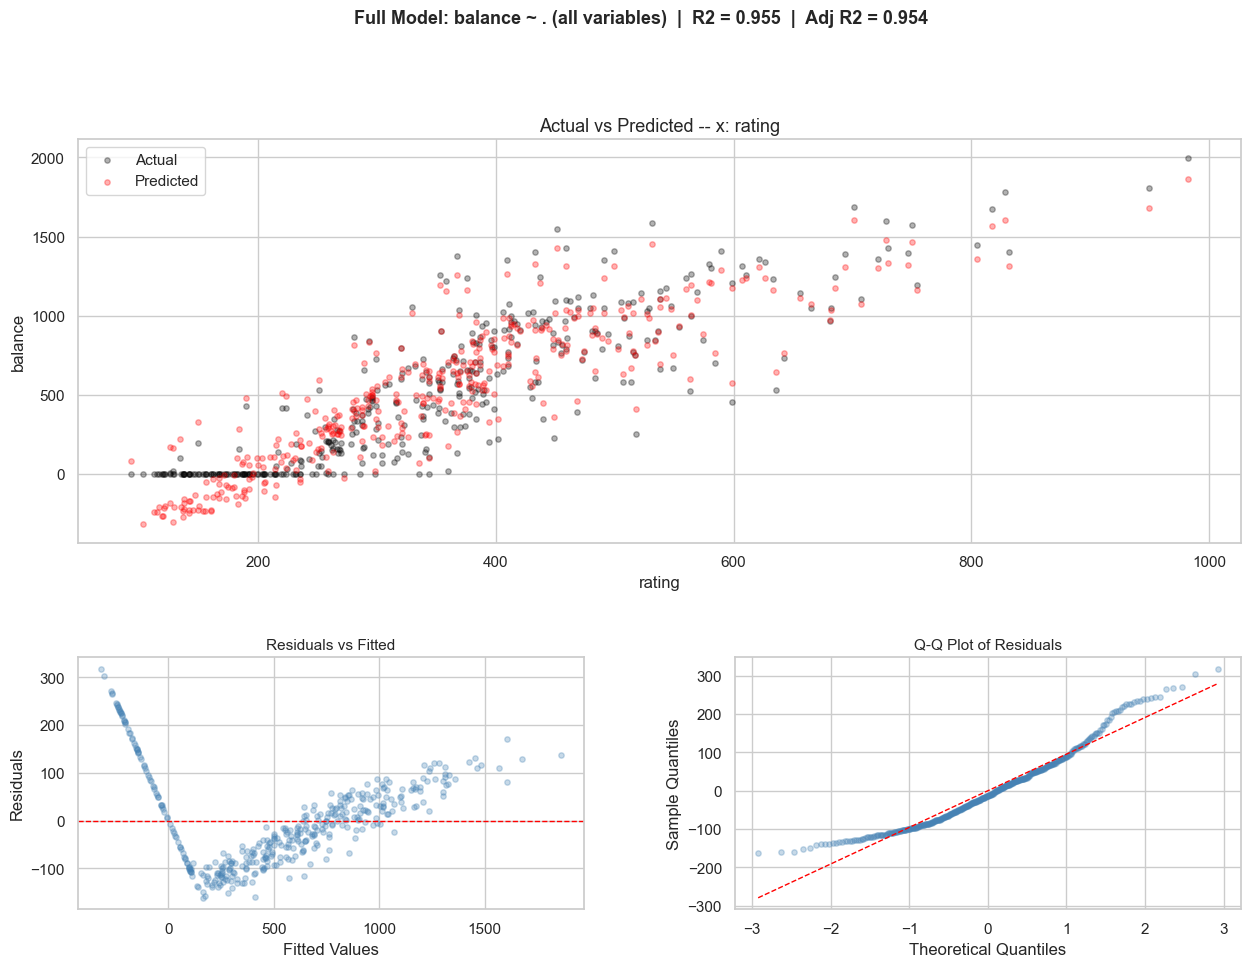

In [17]:
# Identify which columns are categorical (text) and which are numeric
cat_cols = [c for c in credit.columns if credit[c].dtype == 'object' and c != 'balance']
num_cols = [c for c in credit.columns if credit[c].dtype != 'object' and c != 'balance']

# Build the formula: numeric columns as-is, categorical columns wrapped in C()
# C() tells statsmodels to create dummy (0/1) variables for each category
full_formula_terms = num_cols + [f'C({c})' for c in cat_cols]
full_formula       = 'balance ~ ' + ' + '.join(full_formula_terms)
print('Full formula:', full_formula)

# Fit the full model with all variables
colinear_model = fit_and_plot(
    formula=full_formula,
    data=credit,
    model_name='Full Model: balance ~ . (all variables)',
    x_var='rating'
)

### VIF for the Full Model

Now we compute VIF scores to see which predictors are problematically correlated. We expect `limit` and `rating` to have very high VIF scores because they are nearly interchangeable.

In [12]:
# compute_vif takes the right-hand side of the formula (everything after 'balance ~ ')
vif_full = compute_vif(credit, full_formula.replace('balance ~ ', ''))

print('VIF scores for the full model:')
print('(VIF > 5 = concerning, VIF > 10 = serious multicollinearity)')
display(vif_full)

VIF scores for the full model:
(VIF > 5 = concerning, VIF > 10 = serious multicollinearity)


,feature,VIF
7,rating,1282.5400
6,limit,1083.2700
10,education,12.0200
9,age,9.7300
8,cards,8.1800
5,income,7.2400
3,region[T.South],2.8400
2,married[T.Yes],2.6700
0,own[T.Yes],2.0500
4,region[T.West],1.9700


### Model 5 — Remove `limit` to Fix Multicollinearity

Since `limit` and `rating` are nearly identical in what they measure, we drop `limit`. This should make the remaining coefficients more stable and bring VIF scores down.

Model 5 formula: balance ~ income + rating + cards + age + education + own + student + married + region
                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     757.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          4.46e-248
Time:                        21:24:20   Log-Likelihood:                -2415.4
No. Observations:                 400   AIC:                             4853.
Df Residuals:                     389   BIC:                             4897.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------

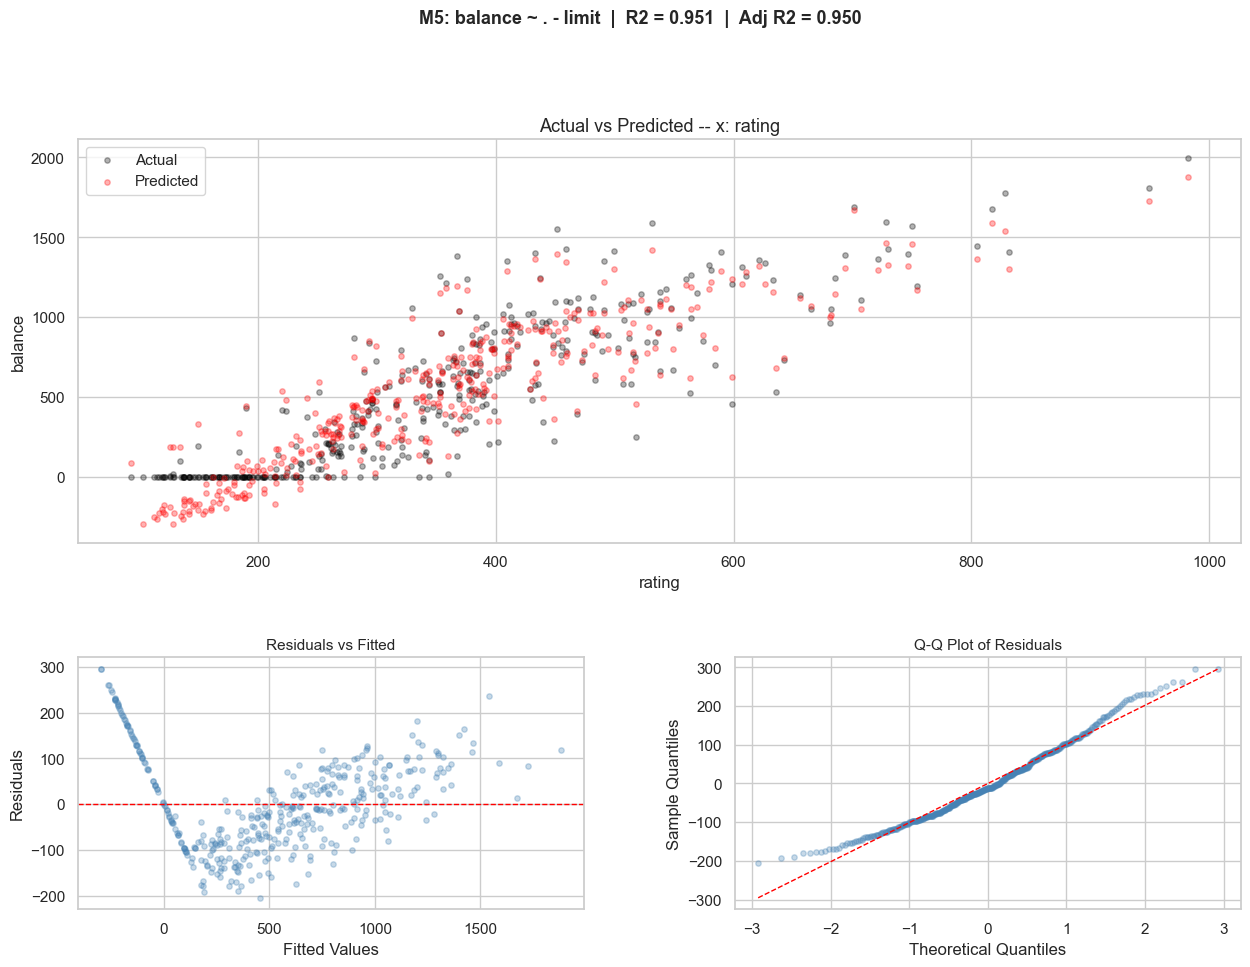

In [13]:
# Remove 'limit' from the predictor list -- it's causing multicollinearity with 'rating'
terms5 = [t for t in full_formula_terms if t != 'limit']
form5  = 'balance ~ ' + ' + '.join(terms5)
print('Model 5 formula:', form5)

model5 = fit_and_plot(
    formula=form5,
    data=credit,
    model_name='M5: balance ~ . - limit',
    x_var='rating'
)

### VIF for Model 5 — After Removing `limit`

After dropping `limit`, VIF scores for the remaining predictors should drop significantly, confirming that multicollinearity has been resolved.

In [14]:
# Check VIF again -- scores should be much lower now that limit is removed
vif5 = compute_vif(credit, form5.replace('balance ~ ', ''))

print('VIF scores for Model 5 (limit removed):')
display(vif5)

VIF scores for Model 5 (limit removed):


,feature,VIF
6,rating,15.5500
9,education,11.6100
8,age,9.3700
5,income,7.2000
7,cards,5.2500
3,region[T.South],2.8200
2,married[T.Yes],2.6000
0,own[T.Yes],2.0400
4,region[T.West],1.9700
1,student[T.Yes],1.1300


### Model 6 — Parsimonious Model

After inspecting Models 3–5, we keep only the predictors that are statistically significant and theoretically meaningful: `income`, `rating`, `age`, and `married`. A simpler model is easier to interpret and less prone to overfitting.

                            OLS Regression Results                            
Dep. Variable:                balance   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     707.4
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          1.39e-178
Time:                        21:26:30   Log-Likelihood:                -2599.4
No. Observations:                 400   AIC:                             5209.
Df Residuals:                     395   BIC:                             5229.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -462.9499     35.47

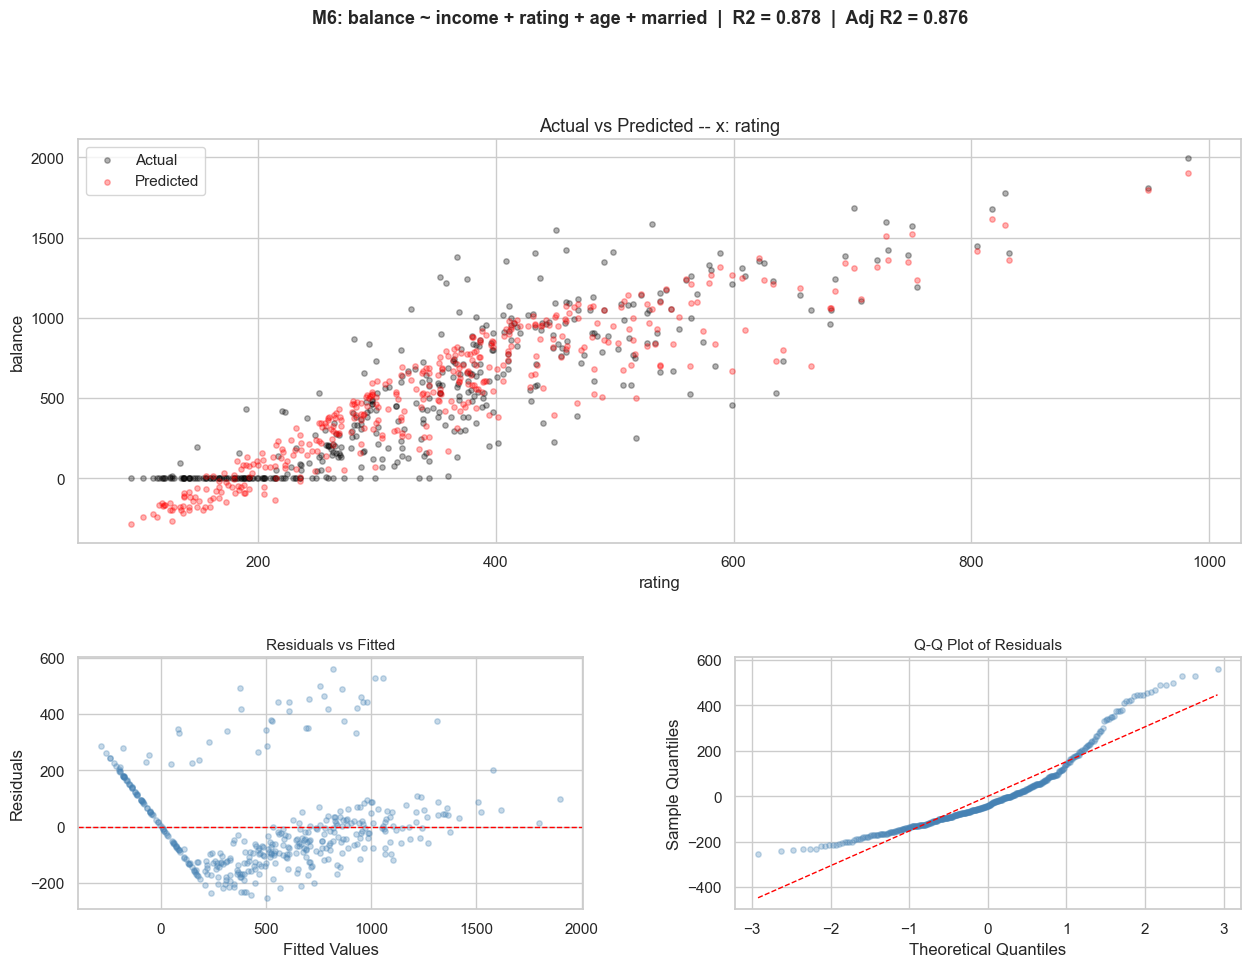

In [18]:
# Parsimonious model: only predictors that are statistically significant
# C(married) tells statsmodels to create a dummy variable: 1 = married, 0 = not married
model6 = fit_and_plot(
    formula='balance ~ income + rating + age + C(married)',
    data=credit,
    model_name='M6: balance ~ income + rating + age + married',
    x_var='rating'
)

### VIF for Model 6

Final check: all VIF scores should be low in this clean, parsimonious model.

In [ ]:
# VIF for the final parsimonious model -- look for VIF < 10
vif6 = compute_vif(credit, 'income + rating + age + C(married)')

print('VIF scores for Model 6 (parsimonious):')
display(vif6)

VIF scores for Model 6 (parsimonious):


,feature,VIF
2,rating,12.3600
1,income,6.5400
3,age,5.2300
0,C(married)[T.Yes],2.3200


## 7. Model Comparison

We compare all models side by side to identify the best specification.

**What to look for:**
- **R-squared**: proportion of balance variance explained — higher is better, but adding any predictor always increases R-squared even if it's not useful
- **Adj. R-squared**: R-squared penalised for extra predictors — use this to compare models with different numbers of variables
- **Residual SE**: average prediction error in dollars — lower is better
- **AIC**: penalised fit metric — lower means better trade-off between fit and model complexity

In [19]:
# Collect all models with readable short names
models = {
    'M0: ~1':              model0,
    'M1: ~rating':         model1,
    'M2: ~income':         model2,
    'M3: ~inc+rat':        model3,
    'M4: ~inc+rat+lim':    model4,
    'M5: ~.-limit':        model5,
    'M6: ~parsimonious':   model6,
}

# Build a comparison DataFrame: one row per metric, one column per model
comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),               # number of observations used
        'R2':          round(m.rsquared, 4),      # variance explained (always increases with more predictors)
        'Adj. R2':     round(m.rsquared_adj, 4),  # penalised R2 -- fairer comparison across models
        'Residual SE': round(np.sqrt(m.mse_resid), 2),  # typical prediction error in dollars
        'AIC':         round(m.aic, 1),            # lower = better fit/complexity trade-off
    }
    for name, m in models.items()
})

print('Model Comparison:')
display(comparison)

Model Comparison:


,M0: ~1,M1: ~rating,M2: ~income,M3: ~inc+rat,M4: ~inc+rat+lim,M5: ~.-limit,M6: ~parsimonious
N,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000
R2,-0.0000,0.7458,0.2150,0.8751,0.8762,0.9512,0.8775
Adj. R2,-0.0000,0.7452,0.2130,0.8745,0.8753,0.9499,0.8763
Residual SE,459.7600,232.0700,407.8600,162.8800,162.3500,102.8900,161.7200
AIC,6040.7000,5494.8000,5945.9000,5212.6000,5211.0000,4852.9000,5208.8000
